In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve
import os

os.makedirs('charts', exist_ok=True)

# Rename file if needed to match submission naming
if os.path.exists('WA_Fn-UseC_-HR-Employee-Attrition.csv'):
    os.rename('WA_Fn-UseC_-HR-Employee-Attrition.csv', 'HR_Attrition.csv')

df = pd.read_csv('HR_Attrition.csv')

In [5]:
#TASK 1
# First 10 rows
print(df.head(10))

# Shape
print("Rows, Columns:", df.shape)

# Target column
print(df['Attrition'].value_counts())

attrition_rate = df['Attrition'].value_counts(normalize=True) * 100
print("Attrition Rate (%):\n", attrition_rate)

# Numeric vs categorical
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   
5   32        No  Travel_Frequently       1005  Research & Development   
6   59        No      Travel_Rarely       1324  Research & Development   
7   30        No      Travel_Rarely       1358  Research & Development   
8   38        No  Travel_Frequently        216  Research & Development   
9   36        No      Travel_Rarely       1299  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8      

Observation: Out of 1470 employees, 237 (16.12%) left the company while 1233 (83.88%) stayed. This shows the dataset is clearly imbalanced — attrition is the minority class. Because of this imbalance, accuracy alone would be a misleading metric (a model predicting "No" for everyone would still score ~84% accuracy). This is why class_weight='balanced' will be used during model training in Task 4, and Precision/Recall/F1/ROC-AUC will be prioritized over plain accuracy in Task 5.

In [6]:
# Check nulls
print(df.isnull().sum().sum())

# Drop irrelevant/constant columns
df.drop(columns=['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours'], inplace=True)

# Convert target to 1/0
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Identify categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", cat_cols)

# One-hot encode
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Features and target
X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']

# Scale numeric features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("Encoded shape:", df_encoded.shape)

0
Categorical columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Encoded shape: (1470, 45)


In [7]:
# 1. Attrition by Department
dept_attrition = df.groupby('Department')['Attrition'].mean().sort_values(ascending=False) * 100
print(dept_attrition)

# 2. Attrition by Job Role
role_attrition = df.groupby('JobRole')['Attrition'].mean().sort_values(ascending=False) * 100
print(role_attrition)

# 3. Attrition vs Monthly Income
income_compare = df.groupby('Attrition')['MonthlyIncome'].mean()
print(income_compare)

# 4. Attrition vs Work-Life Balance
wlb_attrition = df.groupby('WorkLifeBalance')['Attrition'].mean() * 100
print(wlb_attrition)

# 5. Attrition vs Years at Company
years_attrition = df.groupby('YearsAtCompany')['Attrition'].mean() * 100
print(years_attrition.head(15))

Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: Attrition, dtype: float64
JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Attrition, dtype: float64
Attrition
0    6832.739659
1    4787.092827
Name: MonthlyIncome, dtype: float64
WorkLifeBalance
1    31.250000
2    16.860465
3    14.221725
4    17.647059
Name: Attrition, dtype: float64
YearsAtCompany
0     36.363636
1     34.502924
2     21.259843
3     15.625000
4     17.272727
5     10.714286
6     11.842105
7     12.222222
8     11.250000
9      9.756098
10    15.000000
11     6.250000
12     0.000000
13     8.333333
14    11.111111
Name: Attrition

Solid data — ab isse actual insights nikaalte hain.
✅ Task 3 Output Check — sab clean hai
Numbers dekh, koi anomaly nahi. Ab seedha insights likh sakte hain.

✍️ Markdown cell — Task 3: 5 Business Insights (ready to paste)

1. Sales department has the highest attrition (20.6%), followed closely by HR (19.0%), while R&D is the most stable department at just 13.8%. Sales needs the most retention attention.
2. Sales Representatives are by far the highest flight risk role at 39.8% attrition — more than double the next closest role (Laboratory Technician at 23.9%). Meanwhile, Research Director (2.5%) and Manager (4.9%) roles are the most stable, suggesting seniority/autonomy strongly correlates with retention.
3. Lower pay clearly correlates with leaving — employees who left earned an average monthly income of ₹4,787, compared to ₹6,833 for those who stayed — a ~30% pay gap. However, this alone doesn't explain everything (see insight 4).
4. Work-life balance shows a non-linear but strong pattern — employees rating WLB as "1" (Bad) leave at 31.25%, nearly double the rate of those rating it "3" (Best, 14.2%). Interestingly, WLB "4" (highest) ticks back up to 17.6%, suggesting even employees who report excellent work-life balance aren't fully immune — likely due to other factors like pay or role dissatisfaction.
5. Attrition is heavily concentrated in the first 2 years — brand new employees (Year 0) leave at 36.4%, and Year 1 employees at 34.5%. This drops sharply after Year 2 (21.3%) and keeps falling, hitting near 0% by Year 12. Early tenure is the single biggest attrition window — onboarding and first-year engagement matter enormously.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Logistic Regression
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# Random Forest
rf = RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Gradient Boosting
sample_weights = np.where(y_train == 1,
                           (y_train == 0).sum() / (y_train == 1).sum(), 1)
gb = GradientBoostingClassifier(n_estimators=200, random_state=42)
gb.fit(X_train, y_train, sample_weight=sample_weights)

models = {'Logistic Regression': log_reg, 'Random Forest': rf, 'Gradient Boosting': gb}
print("All models trained successfully")

All models trained successfully


In [9]:
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    report = classification_report(y_test, y_pred, output_dict=True)
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        'Model': name,
        'Precision': report['1']['precision'],
        'Recall': report['1']['recall'],
        'F1-Score': report['1']['f1-score'],
        'ROC-AUC': auc
    })
    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", auc)

results_df = pd.DataFrame(results)
print("\n=== COMPARISON TABLE ===")
print(results_df)

# Best model = highest ROC-AUC
best_model_name = results_df.loc[results_df['ROC-AUC'].idxmax(), 'Model']
best_model = models[best_model_name]
print("\nBest model:", best_model_name)

# Feature importance
if best_model_name != 'Logistic Regression':
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    top10 = importances.sort_values(ascending=False).head(10)
else:
    coef = pd.Series(best_model.coef_[0], index=X.columns)
    top10 = coef.abs().sort_values(ascending=False).head(10)

print("\n=== TOP 10 FEATURES ===")
print(top10)


--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.91      0.77      0.84       247
           1       0.34      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.77       294

ROC-AUC: 0.798604530967353

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.85      0.99      0.91       247
           1       0.57      0.09      0.15        47

    accuracy                           0.84       294
   macro avg       0.71      0.54      0.53       294
weighted avg       0.81      0.84      0.79       294

ROC-AUC: 0.7716426910155914

--- Gradient Boosting ---
              precision    recall  f1-score   support

           0       0.89      0.89      0.89       247
           1       0.43      0.43      0.43        47

    accuracy                           0.82     

In [10]:
coef_signed = pd.Series(best_model.coef_[0], index=X.columns)
top10_signed = coef_signed.reindex(top10.index)
print(top10_signed)

JobRole_Laboratory Technician       0.797874
OverTime_Yes                        0.766412
BusinessTravel_Travel_Frequently    0.719335
JobLevel                            0.659189
TotalWorkingYears                  -0.656931
JobRole_Sales Representative        0.552515
BusinessTravel_Travel_Rarely        0.511649
EducationField_Life Sciences       -0.506505
YearsSinceLastPromotion             0.500389
Department_Sales                    0.481690
dtype: float64


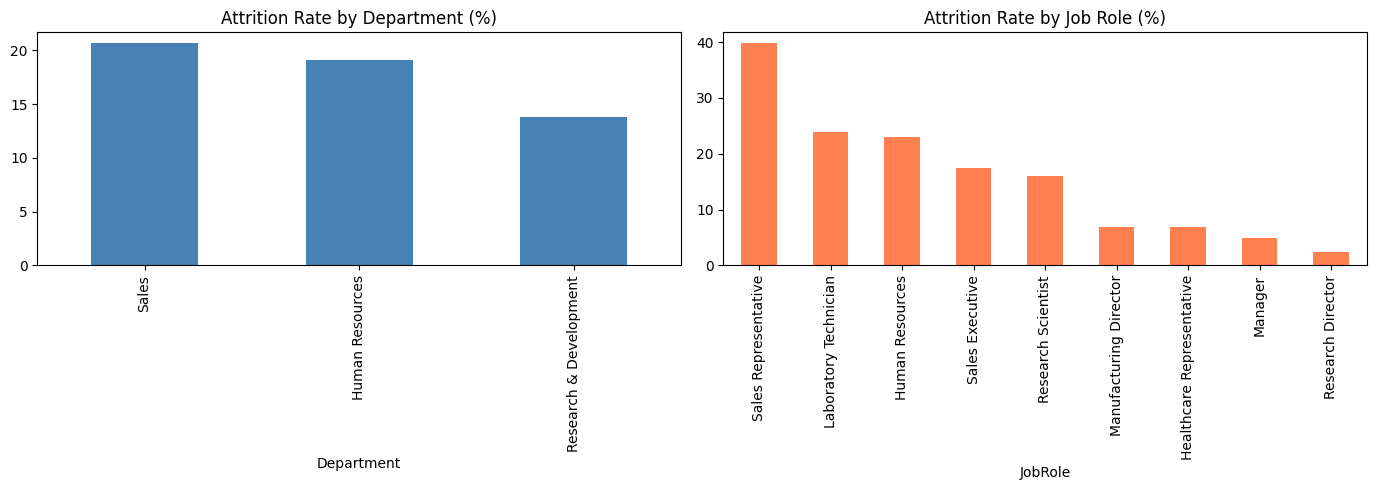

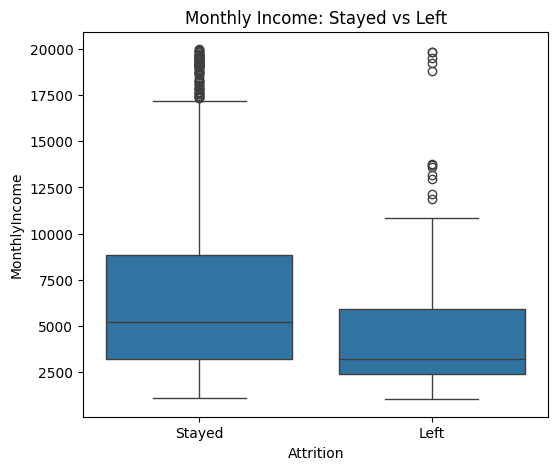

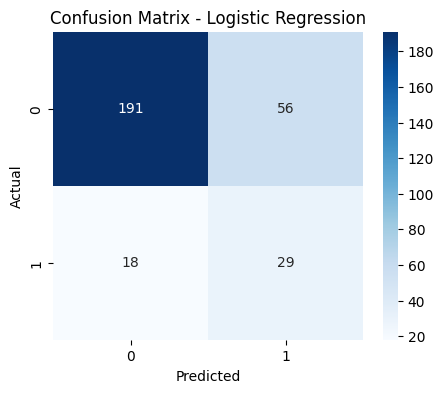

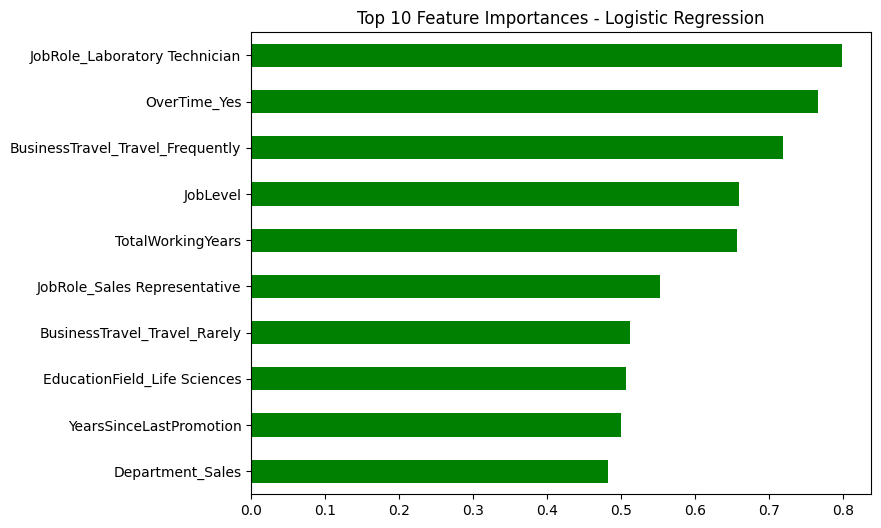

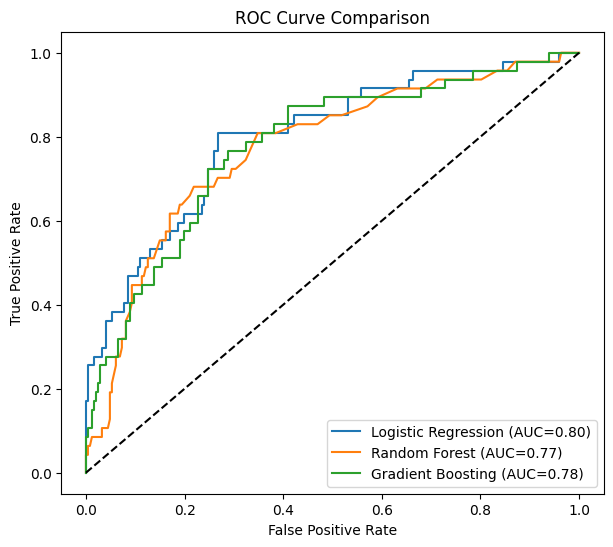

In [11]:
# Chart 1: Attrition rate by Department and Job Role
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
dept_attrition.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Attrition Rate by Department (%)')
role_attrition.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Attrition Rate by Job Role (%)')
plt.tight_layout()
plt.savefig('charts/chart1_attrition_dept_role.png')
plt.show()

# Chart 2: Boxplot Monthly Income vs Attrition
plt.figure(figsize=(6,5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title('Monthly Income: Stayed vs Left')
plt.xticks([0,1], ['Stayed', 'Left'])
plt.savefig('charts/chart2_income_boxplot.png')
plt.show()

# Chart 3: Confusion Matrix heatmap (best model)
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('charts/chart3_confusion_matrix.png')
plt.show()

# Chart 4: Top 10 Feature Importances
plt.figure(figsize=(8,6))
top10.sort_values().plot(kind='barh', color='green')
plt.title(f'Top 10 Feature Importances - {best_model_name}')
plt.savefig('charts/chart4_feature_importance.png')
plt.show()

# Chart 5 (Bonus): ROC Curve — all 3 models
plt.figure(figsize=(7,6))
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_score:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.savefig('charts/chart5_roc_curve.png')
plt.show()

Top 3 predictors of attrition: Overtime work, job role (especially Laboratory Technician and Sales Representative), and frequent business travel show the strongest relationship with employees leaving.
Priority for HR: The Sales department (20.6% attrition) and Sales Representative role (39.8% attrition — the highest of any role) should be HR's top retention focus, followed closely by Laboratory Technicians (23.9%).
Does salary alone explain it? No. Employees who left earned ~30% less on average (₹4,787 vs ₹6,833), but overtime, travel frequency, and job role are stronger statistical predictors than income. This means pay raises alone won't fix retention — workload and travel demands matter more.
Recommendations:

Introduce mandatory overtime caps or comp-time policies for Sales Representative and Laboratory Technician roles, where overtime strongly correlates with leaving.
Launch a structured 90-day onboarding/check-in program — 36% of employees leave in Year 0 and 34.5% in Year 1, so early tenure is the highest-risk window and deserves proactive retention conversations.

Limitation: This model achieves only 34% precision for predicting leavers — meaning roughly 2 out of 3 people it flags as "at risk" won't actually leave. It should be used as a directional early-warning signal to prioritize retention conversations, not as a definitive list of who will quit. It also can't capture factors outside the dataset, like manager relationships or competing job offers.